# **1. Perkenalan Dataset**


Sumber Dataset:
Dataset yang digunakan adalah TikTok App Reviews - Indonesia (Google Play Store)
yang diperoleh dari Kaggle (https://www.kaggle.com/datasets/pandaa12/tiktok-app-reviews-indonesia-google-play-store).

Dataset ini berisi 100.000 ulasan pengguna aplikasi TikTok dari Google Play Store
dalam Bahasa Indonesia, dikumpulkan antara Agustus 2025 hingga Desember 2025.

Informasi kolom:
- Nama User: Nama pengguna yang memberikan ulasan
- Ulasan: Teks ulasan dalam Bahasa Indonesia
- Rating: Skor bintang 1-5 yang diberikan pengguna
- Tanggal: Waktu ulasan diberikan
- Likes: Jumlah thumbs-up pada ulasan
- Versi App: Versi TikTok yang digunakan pengguna

Label Sentimen (hasil label engineering):
- Rating 1-2, Negatif
- Rating 3, Dihapus (netral tidak digunakan)
- Rating 4-5, Positif

# **2. Import Library**

In [ ]:
!pip install PySastrawi -q

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Semua library berhasil diimport")

Semua library berhasil diimport


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
from google.colab import files
import io

uploaded = files.upload()

df = pd.read_csv(io.BytesIO(uploaded['ulasan_tiktok_raw.csv']))

print("Shape dataset:", df.shape)
print("\nNama kolom:", df.columns.tolist())
print("\n5 baris pertama:")
df.head()

Saving ulasan_tiktok_raw.csv to ulasan_tiktok_raw.csv
Shape dataset: (100000, 6)

Nama kolom: ['Nama User', 'Ulasan', 'Rating', 'Tanggal', 'Likes', 'Versi App']

5 baris pertama:


,Nama User,Ulasan,Rating,Tanggal,Likes,Versi App
0,Pengguna Google,aplikasi nya seru banget minn aku suka sering ...,5,2025-12-31 17:31:32,0,43.1.4
1,Pengguna Google,susah mulung skrg,5,2025-12-31 17:28:37,0,43.1.4
2,Pengguna Google,tik tok rusak yg pada ngomong kasar di laporka...,1,2025-12-31 17:25:28,0,40.1.4
3,Pengguna Google,seru,4,2025-12-31 17:23:56,0,NaN
4,Pengguna Google,tiktok ny ga bisa di cptin suka nykrol sendiri...,1,2025-12-31 17:21:25,0,43.1.4


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
# Informasi dasar dataset
print("INFORMASI DASAR DATASET")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nTipe data setiap kolom:")
print(df.dtypes)
print(f"\nJumlah missing values:")
print(df.isnull().sum())
print(f"\nJumlah duplikat: {df.duplicated().sum()}")

INFORMASI DASAR DATASET
Jumlah baris: 100000
Jumlah kolom: 6

Tipe data setiap kolom:
Nama User    object
Ulasan       object
Rating        int64
Tanggal      object
Likes         int64
Versi App    object
dtype: object

Jumlah missing values:
Nama User        0
Ulasan           0
Rating           0
Tanggal          0
Likes            0
Versi App    38641
dtype: int64

Jumlah duplikat: 0


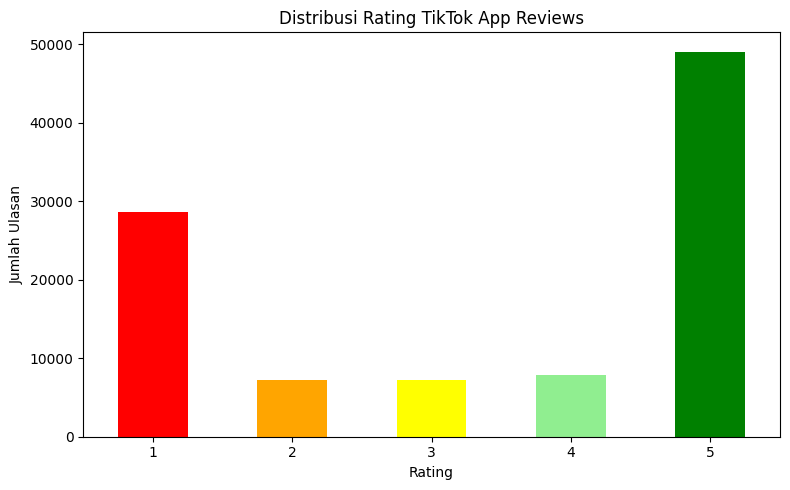


Distribusi Rating:
Rating
1    28586
2     7216
3     7260
4     7859
5    49079
Name: count, dtype: int64

Persentase:
Rating
1    28.6%
2     7.2%
3     7.3%
4     7.9%
5    49.1%
Name: proportion, dtype: object


In [ ]:
# Distribusi Rating
plt.figure(figsize=(8, 5))
df['Rating'].value_counts().sort_index().plot(kind='bar', color=['red','orange','yellow','lightgreen','green'])
plt.title('Distribusi Rating TikTok App Reviews')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nDistribusi Rating:")
print(df['Rating'].value_counts().sort_index())
print(f"\nPersentase:")
print(df['Rating'].value_counts(normalize=True).sort_index().apply(lambda x: f"{x*100:.1f}%"))

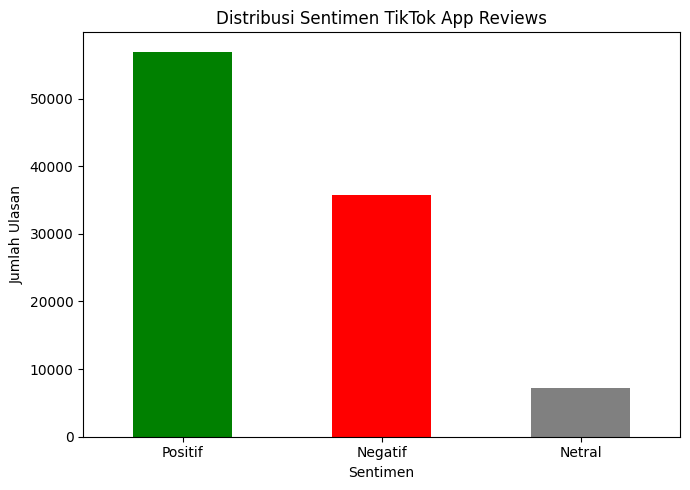


Distribusi Sentimen:
Sentimen
Positif    56938
Negatif    35802
Netral      7260
Name: count, dtype: int64

Persentase:
Sentimen
Positif    56.9%
Negatif    35.8%
Netral      7.3%
Name: proportion, dtype: object


In [ ]:
# Label Engineering
def assign_sentiment(rating):
    if rating <= 2:
        return 'Negatif'
    elif rating >= 4:
        return 'Positif'
    else:
        return 'Netral'

df['Sentimen'] = df['Rating'].apply(assign_sentiment)

# Distribusi sentimen
plt.figure(figsize=(7, 5))
colors = {'Positif': 'green', 'Negatif': 'red', 'Netral': 'gray'}
df['Sentimen'].value_counts().plot(kind='bar',
    color=[colors[x] for x in df['Sentimen'].value_counts().index])
plt.title('Distribusi Sentimen TikTok App Reviews')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nDistribusi Sentimen:")
print(df['Sentimen'].value_counts())
print(f"\nPersentase:")
print(df['Sentimen'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

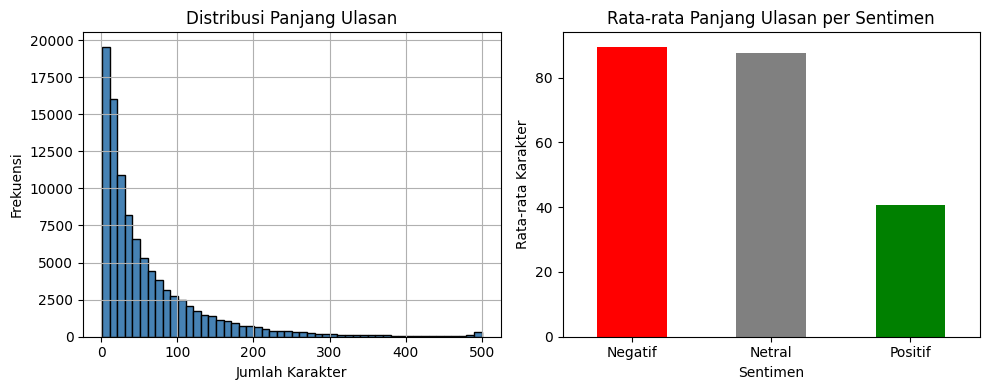


Statistik panjang ulasan:
count    100000.000000
mean         61.567780
std          75.132099
min           1.000000
25%          13.000000
50%          35.000000
75%          81.000000
max         500.000000
Name: panjang_ulasan, dtype: float64


In [ ]:
# Statistik panjang teks
df['panjang_ulasan'] = df['Ulasan'].astype(str).apply(len)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['panjang_ulasan'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribusi Panjang Ulasan')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2)
df.groupby('Sentimen')['panjang_ulasan'].mean().plot(kind='bar', color=['red','gray','green'])
plt.title('Rata-rata Panjang Ulasan per Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Rata-rata Karakter')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nStatistik panjang ulasan:")
print(df['panjang_ulasan'].describe())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
df_clean = df[df['Sentimen'] != 'Netral'].copy()
print(f"Data setelah drop Netral: {df_clean.shape}")
print(f"Distribusi sentimen:\n{df_clean['Sentimen'].value_counts()}")

Data setelah drop Netral: (92740, 8)
Distribusi sentimen:
Sentimen
Positif    56938
Negatif    35802
Name: count, dtype: int64


In [ ]:
print("Missing values sebelum handling:")
print(df_clean.isnull().sum())

df_clean = df_clean.drop(columns=['Nama User', 'Tanggal', 'Likes', 'Versi App', 'Rating', 'panjang_ulasan'])

print(f"\nKolom setelah drop: {df_clean.columns.tolist()}")
print(f"Shape: {df_clean.shape}")
print(f"\nMissing values setelah handling:")
print(df_clean.isnull().sum())

Missing values sebelum handling:
Nama User             0
Ulasan                0
Rating                0
Tanggal               0
Likes                 0
Versi App         35847
Sentimen              0
panjang_ulasan        0
dtype: int64

Kolom setelah drop: ['Ulasan', 'Sentimen']
Shape: (92740, 2)

Missing values setelah handling:
Ulasan      0
Sentimen    0
dtype: int64


In [ ]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['Ulasan_clean'] = df_clean['Ulasan'].apply(clean_text)

print("Contoh hasil text cleaning:")
for i in range(3):
    print(f"\nOriginal : {df_clean['Ulasan'].iloc[i]}")
    print(f"Cleaned  : {df_clean['Ulasan_clean'].iloc[i]}")

Contoh hasil text cleaning:

Original : aplikasi nya seru banget minn aku suka sering sering tambahin sesuatu ya minn aku suka banget make tiktok kalo lagi sedih/seneng/dll minn hehee Mangat terus minn moga kedepan nya ada update an yang lebih menarik ya minn🤍🤍🫂
Cleaned  : aplikasi nya seru banget minn aku suka sering sering tambahin sesuatu ya minn aku suka banget make tiktok kalo lagi sedihsenengdll minn hehee mangat terus minn moga kedepan nya ada update an yang lebih menarik ya minn

Original : susah mulung skrg
Cleaned  : susah mulung skrg

Original : tik tok rusak yg pada ngomong kasar di laporkan ngak ada pelanggaran sistem gblok 🤡🤮
Cleaned  : tik tok rusak yg pada ngomong kasar di laporkan ngak ada pelanggaran sistem gblok


In [ ]:
stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return stemmer.stem(text)

print("Memproses stopword removal...")
df_clean['Ulasan_no_stopword'] = df_clean['Ulasan_clean'].apply(remove_stopwords)

print("Memproses stemming (ini membutuhkan waktu beberapa menit)...")
df_clean['Ulasan_processed'] = df_clean['Ulasan_no_stopword'].apply(stem_text)

print("Selesai!")
print("\nContoh hasil preprocessing:")
for i in range(3):
    print(f"\nOriginal  : {df_clean['Ulasan'].iloc[i]}")
    print(f"Processed : {df_clean['Ulasan_processed'].iloc[i]}")

Memproses stopword removal...
Memproses stemming (ini membutuhkan waktu beberapa menit)...
Selesai!

Contoh hasil preprocessing:

Original  : aplikasi nya seru banget minn aku suka sering sering tambahin sesuatu ya minn aku suka banget make tiktok kalo lagi sedih/seneng/dll minn hehee Mangat terus minn moga kedepan nya ada update an yang lebih menarik ya minn🤍🤍🫂
Processed : aplikasi nya seru banget minn suka tambahin ya minn suka banget make tiktok kalo sedihsenengdll minn hehee mangat minn moga depan nya update an tarik ya minn

Original  : susah mulung skrg
Processed : susah mulung skrg

Original  : tik tok rusak yg pada ngomong kasar di laporkan ngak ada pelanggaran sistem gblok 🤡🤮
Processed : tik tok rusak yg ngomong kasar lapor ngak langgar sistem gblok


In [ ]:
df_clean['label'] = df_clean['Sentimen'].map({'Positif': 1, 'Negatif': 0})

df_final = df_clean[['Ulasan_processed', 'label']].copy()
df_final = df_final.rename(columns={'Ulasan_processed': 'teks'})

df_final = df_final[df_final['teks'].str.strip() != '']
df_final = df_final.dropna()

print(f"Shape data final: {df_final.shape}")
print(f"\nDistribusi label:")
print(df_final['label'].value_counts())
print(f"\nLabel 0 = Negatif, Label 1 = Positif")

X_train, X_test, y_train, y_test = train_test_split(
    df_final['teks'],
    df_final['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_final['label']
)

print(f"\nUkuran data train: {X_train.shape}")
print(f"Ukuran data test : {X_test.shape}")

df_final.to_csv('ulasan_tiktok_preprocessing.csv', index=False)
print("\nDataset preprocessing tersimpan: ulasan_tiktok_preprocessing.csv")

Shape data final: (90353, 2)

Distribusi label:
label
1    54816
0    35537
Name: count, dtype: int64

Label 0 = Negatif, Label 1 = Positif

Ukuran data train: (72282,)
Ukuran data test : (18071,)

Dataset preprocessing tersimpan: ulasan_tiktok_preprocessing.csv
